In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu')
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 4


In [2]:
import importlib_resources
from jnkepler.jaxttv.infer import *
from jnkepler.nbodytransit import *


In [3]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc

# Load data

In [4]:
d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354632  0.001001
1             1      2  1733.115272  0.002002
2             1      3  1741.996592  0.001416
3             1      5  1759.759235  0.002002
4             1      6  1768.637553  0.003609
..          ...    ...          ...       ...
106           3     42  3354.302036  0.002238
107           3     43  3392.660442  0.001014
108           3     47  3546.074046  0.001416
109           3     49  3622.769837  0.002238
110           3     50  3661.127242  0.001533

[111 rows x 4 columns]


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_54648/1082065755.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [5]:
tcobs = [jnp.array(d.Tc[d.Planet_num==j+1]) for j in range(3)]
errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+1]) for j in range(3)]
p_init = [8.88020257, 28.58140011, 38.35180318]


t_start = 1715.  # start of integration
t_end = 3670.
dt = 0.1 # integration timestep

In [6]:
print(tcobs)
print(errorobs)

[Array([1715.3546315, 1733.1152715, 1741.9965925, 1759.7592345,
       1768.6375525, 1786.3991935, 1795.2835175, 1804.1588325,
       1813.0421555, 1821.9184715, 1830.8017945, 1839.6811135,
       1875.2013925, 1892.9630335, 1901.8433535, 1910.7226725,
       1919.6019915, 1964.0035915, 1972.8839115, 1981.7652325,
       1990.6445515, 1999.5248715, 2008.4051915, 2425.7812325,
       2434.6625535, 2443.5428735, 2621.1512755, 2630.0275915,
       2647.7892325, 2656.6685515, 2701.0721535, 2718.8327935,
       2727.7111115, 2736.5914315, 2798.7546725, 2807.6349925,
       2816.5143115, 2825.3956325, 2834.2769535, 2843.1562725,
       2852.0375935, 2914.1968305, 2923.0781515, 2931.9574705,
       2940.8397925, 2949.7201125, 2958.6014335, 3296.0505905,
       3340.4541925, 3349.3345125, 3358.2128305, 3367.0961535,
       3375.9744715, 3384.8537905, 3393.7381145, 3402.6174335,
       3420.3750705, 3438.1377125, 3447.0180325, 3455.8983525,
       3464.7786725, 3473.6619955, 3535.8242355, 3544.

In [7]:
# detrended light curves around transits; here simultaneous transit is excluded
dlc = pd.read_csv("TOI1339_lc_photodyn.csv")
time_obs = jnp.array(dlc['time'])
flux_obs = jnp.array(dlc['flux']) - 1.  # normalize around 0
error_obs = jnp.array(dlc['flux_err'])

# Get the sorting indices
sort_idx = np.argsort(time_obs)

# Apply the same reordering to all arrays
time_obs = time_obs[sort_idx]
flux_obs = flux_obs[sort_idx]
error_obs = error_obs[sort_idx]
print(time_obs)
print(dlc)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82669654 3662.82692802
 3662.8271595 ]
                time      flux  flux_err
0        1790.657779  0.999069  0.000578
1        1790.659168  0.999941  0.000580
2        1790.660557  0.999068  0.000580
3        1790.661946  0.999770  0.000579
4        1790.663335  0.999724  0.000579
...              ...       ...       ...
1954365  3662.826234  0.998714  0.000903
1954366  3662.826465  0.998010  0.000903
1954367  3662.826697  1.001218  0.000904
1954368  3662.826928  0.998057  0.000903
1954369  3662.827159  1.000882  0.000905

[1954370 rows x 3 columns]


In [8]:
window = 0.2  # days
time_segments, flux_segments, error_segments = [], [], []

for planet_idx, tplanet in enumerate(tcobs):
    for t0 in tplanet:
        mask = (time_obs > t0 - window) & (time_obs < t0 + window)
        time_segments.append(time_obs[mask])
        flux_segments.append(flux_obs[mask])
        error_segments.append(error_obs[mask])

# Concatenate segments
time_obs_trim = np.concatenate(time_segments)
flux_obs_trim = np.concatenate(flux_segments)
error_obs_trim = np.concatenate(error_segments)

time_obs = jnp.array(time_obs_trim)
flux_obs = jnp.array(flux_obs_trim)
error_obs = jnp.array(error_obs_trim)
print(time_obs)
print(len(time_obs))

[1715.15471818 1715.15610709 1715.15749599 ... 3661.32672647 3661.32695795
 3661.32718943]
138651


In [9]:
# Kepler long cadence in days
kepler_lc = 29.4 / 60 / 24  # ~0.02042 days

def bin_lc(time, flux, error, lc_bin):
    """
    Bin time, flux, and error arrays to a specified cadence (lc_bin in days)
    """
    start = time[0]
    end = time[-1]
    bins = jnp.arange(start, end + lc_bin, lc_bin)

    binned_time = []
    binned_flux = []
    binned_error = []

    for i in range(len(bins)-1):
        mask = (time >= bins[i]) & (time < bins[i+1])
        if jnp.any(mask):
            binned_time.append(jnp.mean(time[mask]))
            binned_flux.append(jnp.mean(flux[mask]))
            # propagate error assuming independent measurements
            binned_error.append(jnp.sqrt(jnp.sum(error[mask]**2)) / jnp.sum(mask))

    return jnp.array(binned_time), jnp.array(binned_flux), jnp.array(binned_error)

# Split before/after 2200 days
mask_before = time_obs < 2200
mask_after  = time_obs >= 2200

t_before, f_before, e_before = bin_lc(time_obs[mask_before], flux_obs[mask_before], error_obs[mask_before], kepler_lc)
t_after,  f_after,  e_after  = bin_lc(time_obs[mask_after], flux_obs[mask_after], error_obs[mask_after], kepler_lc)

# Combine
time_obs = jnp.concatenate([t_before, t_after])
flux_obs = jnp.concatenate([f_before, f_after])
error_obs = jnp.concatenate([e_before, e_after])

print(len(time_obs))

2181


# Initialize

In [11]:
nt = NbodyTransit(t_start, t_end, dt, tcobs, p_init, errorobs=errorobs, print_info=True)
nt.set_lcobs(time_obs)
# nt.set_lcobs(time_obs, exposure_time=2/1440.)
# nt.set_lcobs(time_obs, exposure_time=(1/3)/1440., supersample_factor=3)  # 20 second

# number of transiting planets:    3
# integration starts at:           1715.00
# first transit time in data:      1715.35
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.1000 (1/88 of innermost period)

# exposure time (min):             29.4
# supersampling factor:            10


In [12]:
print(nt.times_lc)  # should be a JAX array of times
print(time_obs.shape, flux_obs.shape, error_obs.shape)
print([x.shape for x in tcobs])

[1715.16444054 1715.18527417 1715.2061078  ... 3661.29003734 3661.31040733
 3661.32394875]
(2181,) (2181,) (2181,)
[(72,), (22,), (17,)]


# TTV only optimization

In [13]:
param_bounds_ttv = ttv_default_parameter_bounds(nt)#, emax=0.5)

# running least squares optimization...


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# objective function: 25923.16 --> 176.36 (111 data)
# elapsed time: 17.5 sec


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


{'period': array([ 8.88024502, 28.5813454 , 38.35153685]), 'ecosw': array([ 0.18990538, -0.03995101, -0.03602439]), 'esinw': array([ 0.04580428, -0.02457531, -0.02083838]), 'tic': array([1715.35561136, 1726.05450433, 1743.55710861]), 'lnpmass': array([-10.53080313, -11.38549601, -11.92454588]), 'pmass': Array([2.67011712e-05, 1.13590473e-05, 6.62575735e-06], dtype=float64)}


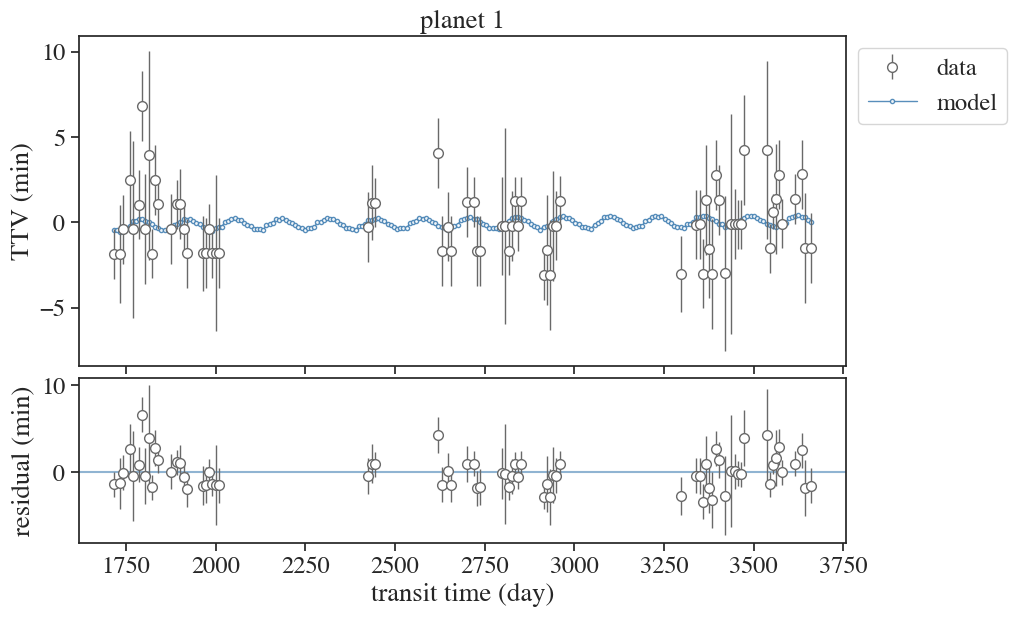

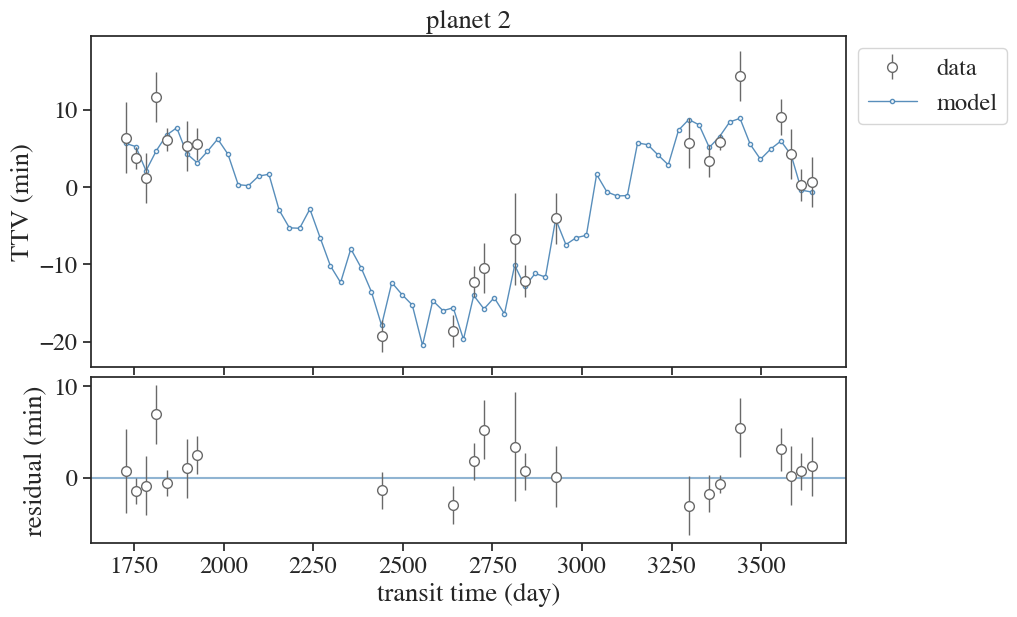

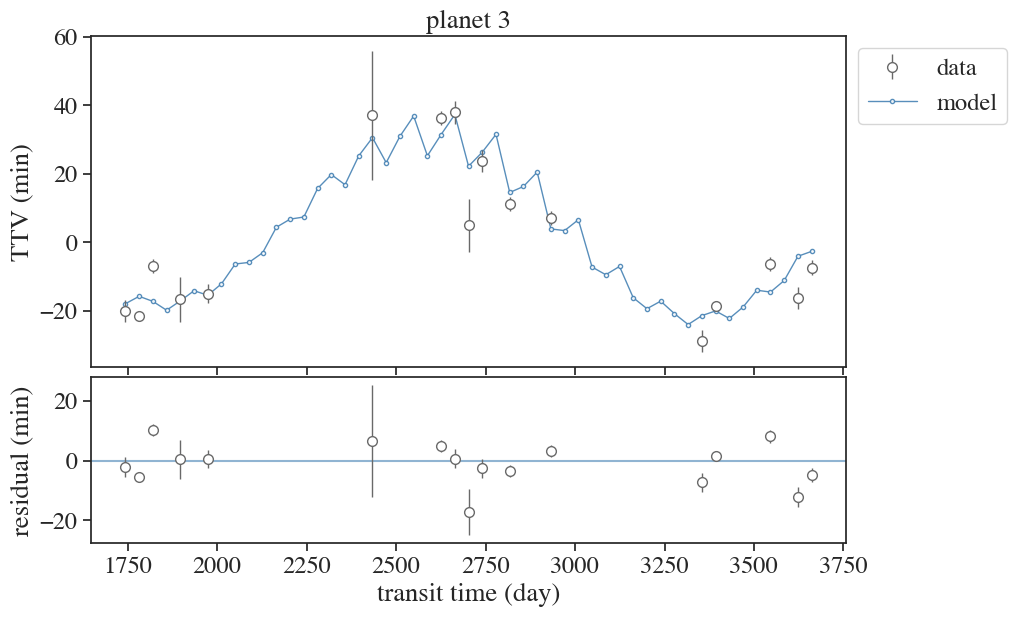

In [24]:
# p_init = np.array([8.87594849, 28.579657965796578, 38.35013501350135, 
#                    0.0, 0.05, 0.05, 
#                    0.0, 0.05, 0.05, 
#                    1715.3049092, 1726.05430737, 1743.55228223, 
#                    -10.41341358, -10.92425031, -11.61737528])

p_init = np.array([8.88020257, 28.58140011, 38.35180318,
                   0.16996202, -0.09855112, -0.0863744,
                   0.09494596, -0.04802669, -0.04114657,
                   1715.3554624, 1726.054591, 1743.55713087,
                   -10.3954937, -11.3564078 , -11.88909652,

    
])

# p_init = np.array([28.579657965796578, 38.35013501350135, 
#                    -0.21369753, -0.18361236, 
#                    -0.23016884, -0.19734158, 
#                    1726.05430737, 1743.55228223, 
#                    -10.97106092, -11.30491702])

popt = ttv_optim_curve_fit(nt, param_bounds_ttv)#, p_init=p_init)
print(popt)

# fractional energy error (symplectic, dt=1.00e-01): 2.17e-11
# fractional energy error (symplectic, dt=8.88e-03): 8.61e-13
# max difference in tc: 7.55e-07 days (0.07 sec)


sample: 100%|█| 1000/1000 [00:00<00:00, 2019.08it/s, 3 steps of size 6.21e-01. a



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      1.27      0.34      1.26      0.70      1.82    222.95      1.00
     lnvar     -0.30      0.24     -0.29     -0.71      0.08    176.32      1.00

Number of divergences: 0


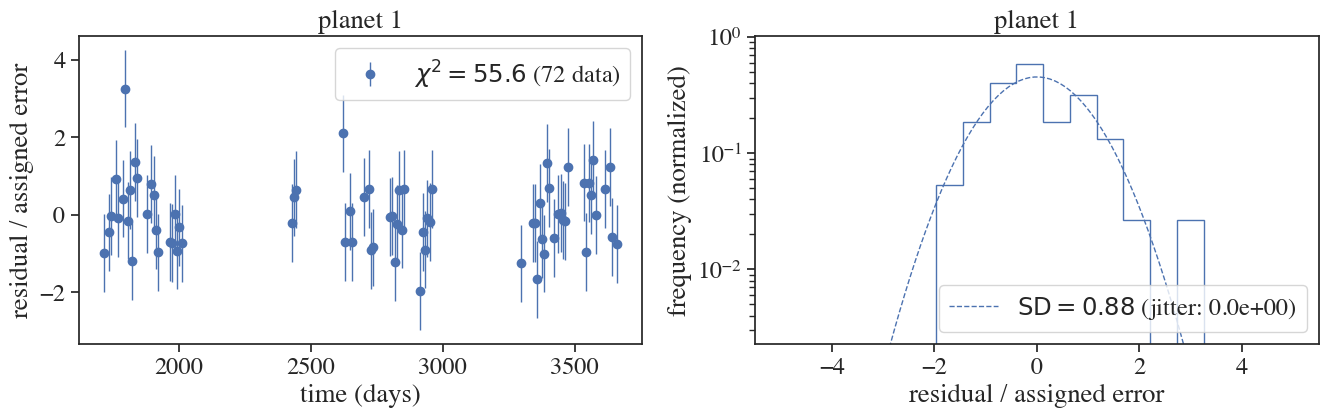

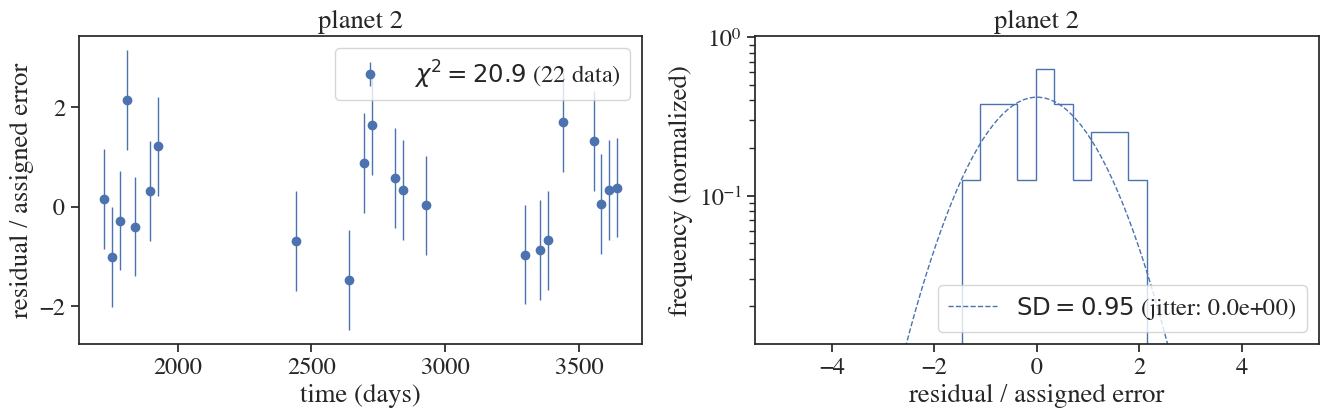

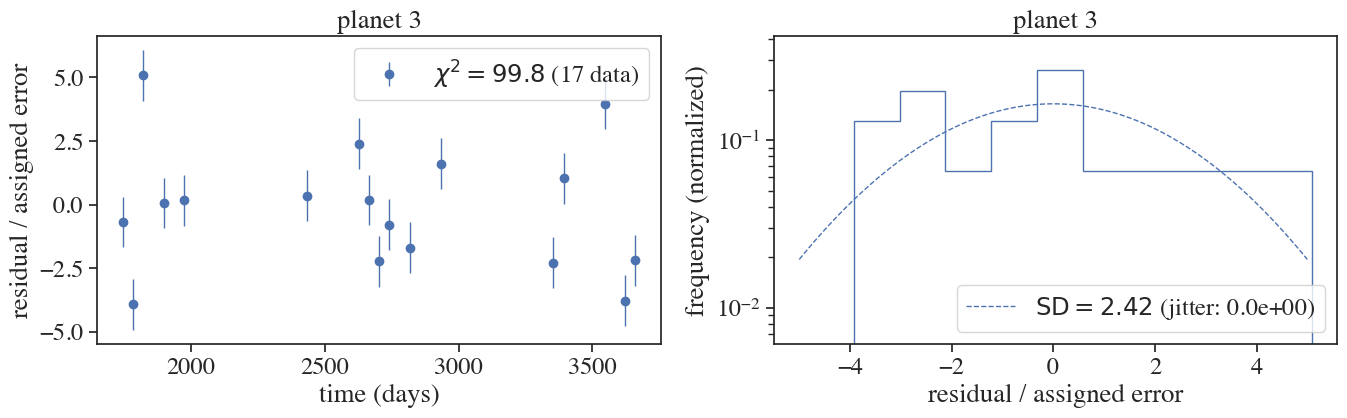

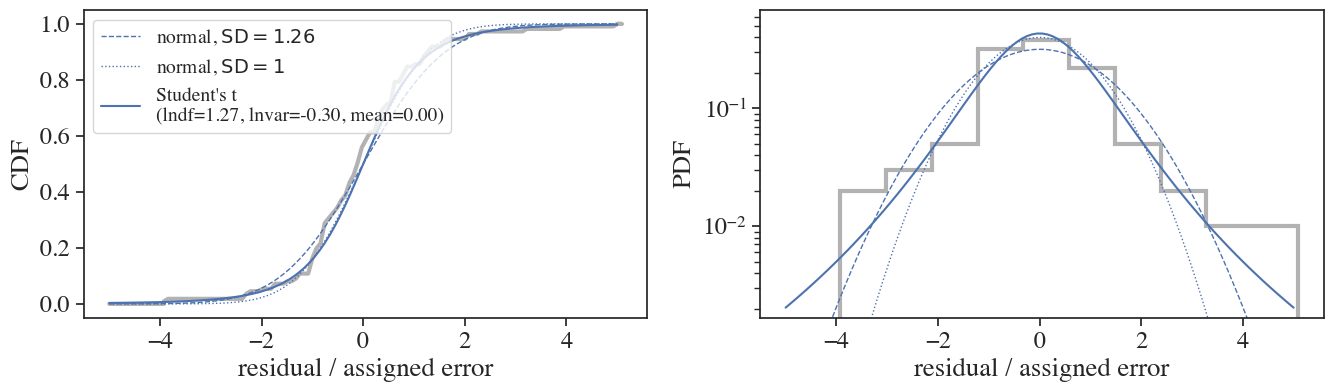

In [15]:
tc, _ = nt.check_timing_precision(popt)

pdic_normal, pdic_student = nt.check_residuals(popt)#, jitters=jitters)
plt.show()

In [ ]:
## import pickle 
with open('mcmc_runs/1339_jnkep_initial_fit_data_photodyn.pkl', 'wb') as f:
    pickle.dump({'jttv': nt, 'popt': popt, 'param_bounds': param_bounds_ttv}, f)

print('Initial fit data saved successfully')

# Transit parameter optimization

In [16]:
from jnkepler.infer import optim_svi

In [17]:
popt["smass"] = 0.81

In [18]:
# keys_ttv = ["ecosw", "esinw", "pmass", "period", "tic"]
# keys_transit = ["radius_ratio", "b", "srad", "q1", "q2", "meanflux"]
# param_bounds_transit = {
#     "q1": [jnp.array(0), jnp.array(1.)],
#     "q2": [jnp.array(0), jnp.array(1.)],
#     "radius_ratio":  [jnp.ones(3)*0.000001, jnp.ones(3)*0.07],
#     "b": [jnp.zeros(3), jnp.ones(3)*0.99],
#     "srad": [jnp.array(0.5), jnp.array(1.1)],
#     "meanflux": [jnp.array(-1e-4), jnp.array(1e-4)]
# }

keys_ttv = ["ecosw", "esinw", "pmass", "period", "tic"]
keys_transit = ["radius_ratio", "b", "srad", "q1", "q2", "meanflux"]
param_bounds_transit = {
    "q1": [jnp.array(0), jnp.array(1.)],
    "q2": [jnp.array(0), jnp.array(1.)],
    "radius_ratio":  [jnp.ones(3)*0.005, jnp.ones(3)*0.08],
    "b": [jnp.zeros(3), jnp.ones(3)*0.9],
    "srad": [jnp.array(0.75), jnp.array(1.25)],
    "meanflux": [jnp.array(-1e-4), jnp.array(1e-4)]
}


In [20]:
import celerite2
from celerite2.jax import terms as jax_terms

def model_fix_ttv(par_dict, param_bounds_transit):
    par = {}

    for key in keys_ttv + ["smass"]:
        par[key] = par_dict[key]

    for key in keys_transit:
        if key in ["q1", "q2", "b"]:
            par[key] = numpyro.sample(key, dist.Uniform(param_bounds_transit[key][0], param_bounds_transit[key][1]))
        else:
            par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0+1.))
            par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0])

    
    fluxmodel, tcmodel = nt.get_flux(par)
    numpyro.deterministic("tcmodel", tcmodel)
    fluxmodel = numpyro.deterministic("fluxmodel", fluxmodel)    
    residual = numpyro.deterministic("residual", flux_obs - fluxmodel - par["meanflux"])
    numpyro.deterministic("normed_residual", residual / error_obs)
    
    # GP likelihood
    lna = numpyro.sample("lna", dist.Uniform(low=-14, high=-4))
    lnc = numpyro.sample("lnc", dist.Uniform(low=-5, high=1))
    lnjitter = numpyro.sample("lnjitter", dist.Uniform(low=-14, high=-4))
    jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))
    kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    gp = celerite2.jax.GaussianProcess(kernel, mean=0.0)
    gp.compute(nt.times_lc, diag=error_obs**2 + jitter**2)
    numpyro.sample("obs", gp.numpyro_dist(), obs=residual)
    numpyro.deterministic("gppred", gp.predict(residual))

In [20]:
popt_transit = optim_svi(model_fix_ttv, 1e-2, 5000, 
                         # p_initial = par_init, 
                         par_dict=popt, 
                         param_bounds_transit=param_bounds_transit)

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
100%|█| 5000/5000 [44:25<00:00,  1.88it/s, init loss: -10932.5816, avg. loss [47


In [12]:
from scipy.stats import norm 
def check_residuals(p):
    bins = np.linspace(-7, 7, 100)
    plt.yscale("log")
    plt.xlabel("normalized residual from GP mean")
    res = (p['residual'] - p["gppred"]) / error_obs
    plt.hist(res, bins=bins, density=True, alpha=0.6, label="SD=%.2f"%np.std(res))
    plt.ylim(plt.gca().get_ylim())
    plt.plot(bins, norm.pdf(bins), color='gray', label='standard normal')
    plt.legend(loc='best')
    plt.ylabel("PDF");

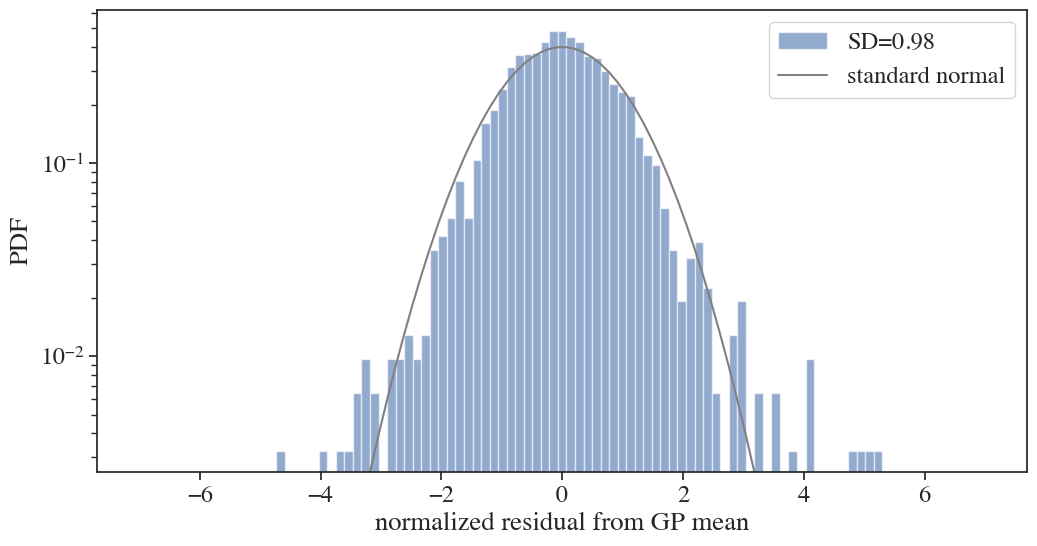

In [13]:
check_residuals(popt_transit)

In [ ]:
# import jax, numpyro, celerite2
# print(jax.__version__)
# print(numpyro.__version__)
# print(celerite2.__version__)

## optimizing full photodynamical model

In [23]:
popt_ttv_scaled = scale_pdic(popt, param_bounds_ttv)
popt_full = popt_transit.copy()
popt_full.update(popt_ttv_scaled)

In [24]:
popt_full['lnode_innder'] = jnp.zeros(2)

In [18]:
def model_full(param_bounds_ttv, param_bounds_transit):
    """full photodynamical model
    
        - noise model is iid gaussian; we could've used other noise model (e.g., GP, Student's t)
        - we could've fitted mean flux as well
        - stellar mass is fixed to 1Msun and only radius is floated, because only mean stellar density is constrained from this model;
          so pmass is mass ratio and stellar radius (srad) is in units of Rsun/(Mstar/Msun)**(1./3.)
        - impact parameters are restricted to be positive but this could be relaxed
        - longitude of ascending node (lnode) is measured with respect to the outermost transiting planet

    """
    # fix stellar mass to 1Msun without losing generality
    par = {"smass": 1.}

    # TTV parameters
    for key in keys_ttv:
        par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_ttv[key][0]*0, param_bounds_ttv[key][0]*0+1.))
        par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_ttv[key][1] - param_bounds_ttv[key][0]) + param_bounds_ttv[key][0])

    # add longitude of ascending node; prior Unif(-1, 1)
    lnode_inner = numpyro.sample("lnode_inner", dist.Uniform(-jnp.ones(2), jnp.ones(2)))
    par["lnode"] = numpyro.deterministic("lnode", jnp.hstack([lnode_inner, 0.]))

    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    # transit parameters (though note that b is used to fix inclination along with other TTV parameters)
    for key in keys_transit:
        if key in ["q1", "q2", "b"]:
            par[key] = numpyro.sample(key, dist.Uniform(param_bounds_transit[key][0], param_bounds_transit[key][1]))
        else:
            par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0+1.))
            par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0])
    
    # compute model (tcmodel is not used)
    fluxmodel, tcmodel = nt.get_flux(par)
    numpyro.deterministic("tcmodel", tcmodel)
    numpyro.deterministic("fluxmodel", fluxmodel)  

    # GP likelihood  
    residual = numpyro.deterministic("residual", flux_obs - fluxmodel - par["meanflux"])
    numpyro.deterministic("normed_residual", residual / error_obs)
    lna = numpyro.sample("lna", dist.Uniform(low=-14, high=-4))
    lnc = numpyro.sample("lnc", dist.Uniform(low=-5, high=1))
    lnjitter = numpyro.sample("lnjitter", dist.Uniform(low=-14, high=-4))
    jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))
    
    kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    gp = celerite2.jax.GaussianProcess(kernel, mean=0.0)
    gp.compute(nt.times_lc, diag=error_obs**2 + jitter**2)
    
    numpyro.sample("obs", gp.numpyro_dist(), obs=residual)
    numpyro.deterministic("gppred", gp.predict(residual))

In [26]:
popt_full = optim_svi(model_full, 1e-2, 5000, 
                      p_initial=popt_full, 
                      param_bounds_ttv=param_bounds_ttv, 
                      param_bounds_transit=param_bounds_transit)

100%|█| 5000/5000 [49:07<00:00,  1.70it/s, init loss: -12734.4446, avg. loss [47


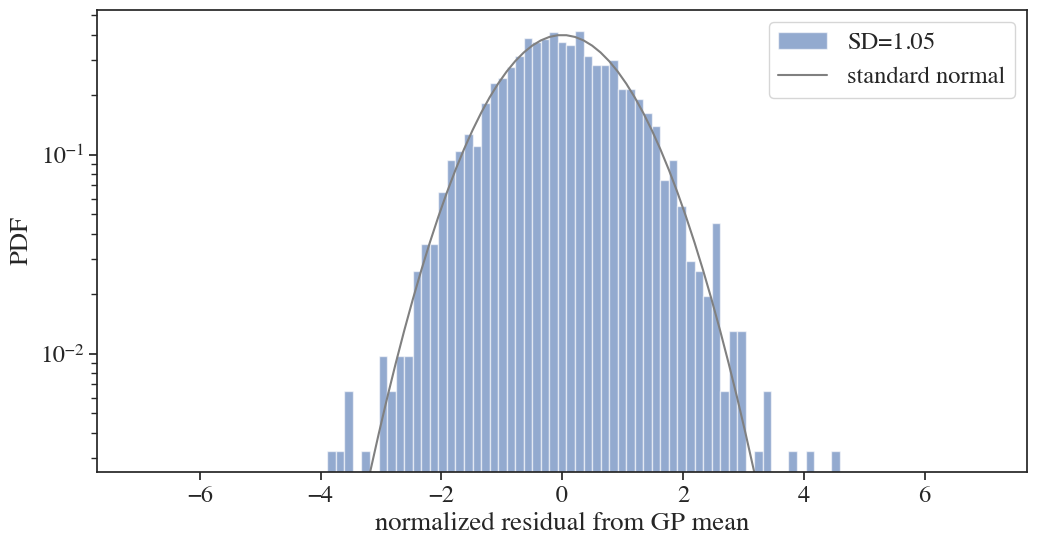

In [14]:
check_residuals(popt_full)

In [30]:
import pickle 
with open('1339_jnkep_initial_fit_photodyn.pkl', 'wb') as f:
    pickle.dump({'nt': nt, 
                 'popt_transit': popt_transit, 
                 'popt_full': popt_full, 
                 'param_bounds': param_bounds_ttv, 
                 'param_bounds_transit': param_bounds_transit, 'keys_ttv': keys_ttv, 'keys_transit': keys_transit}, f)

print('Initial fit data saved successfully')

Initial fit data saved successfully


# Running the HMC

In [10]:
import pickle

# Load the saved data
with open('1339_jnkep_initial_fit_photodyn.pkl', 'rb') as f:
    data = pickle.load(f)

# Access the variables
nt = data['nt']
popt_transit = data['popt_transit']
popt_full = data['popt_full']
param_bounds_ttv = data['param_bounds']
param_bounds_transit = data['param_bounds_transit']
keys_ttv = data['keys_ttv']
keys_transit = data['keys_transit']


In [12]:
print(popt_transit)
print('\n')
print(popt_full)

{'radius_ratio_scaled': Array([0.39960425, 0.35803625, 0.34915583], dtype=float64), 'radius_ratio': Array([0.03497032, 0.03185272, 0.03118669], dtype=float64), 'b': Array([0.73361122, 0.75288958, 0.69771773], dtype=float64), 'srad_scaled': Array(0.88068761, dtype=float64), 'srad': Array(1.1903438, dtype=float64), 'q1': Array(0.86223179, dtype=float64), 'q2': Array(0.19648156, dtype=float64), 'meanflux_scaled': Array(0.64839125, dtype=float64), 'meanflux': Array(2.96782504e-05, dtype=float64), 'tcmodel': Array([1715.35490409, 1733.11548478, 1741.99600054, 1759.75679069,
       1768.63736021, 1786.3981371 , 1795.27846306, 1804.15871497,
       1813.03902404, 1821.91921612, 1830.79942228, 1839.67973051,
       1875.20097078, 1892.96193598, 1901.84236613, 1910.72284799,
       1919.60315808, 1964.00447077, 1972.88474889, 1981.76502472,
       1990.64530328, 1999.52576634, 2008.40613125, 2425.78232256,
       2434.66267138, 2443.54305567, 2621.14941204, 2630.02970037,
       2647.7902342 , 

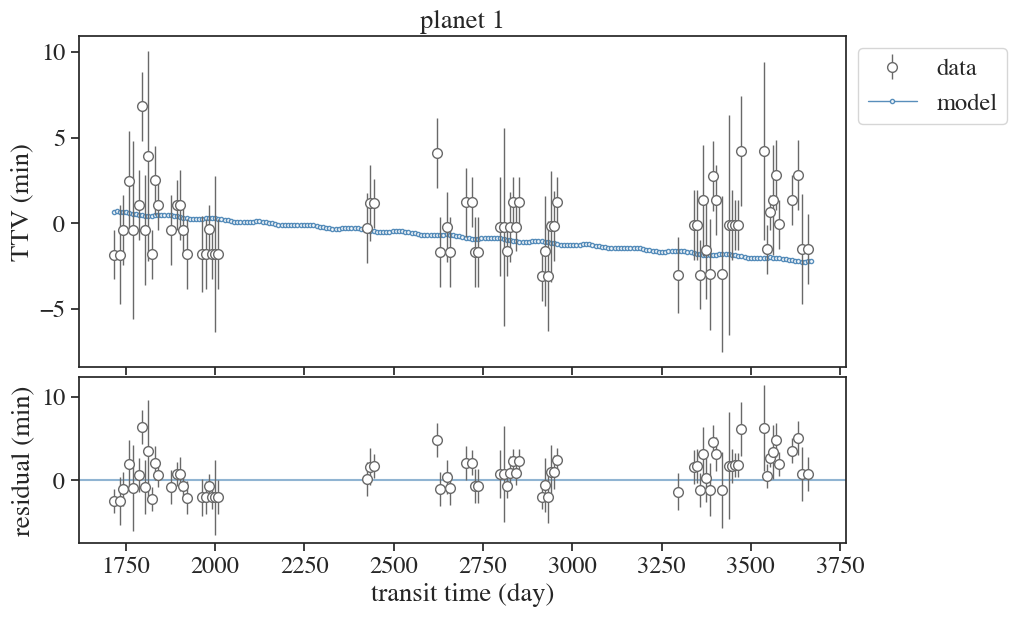

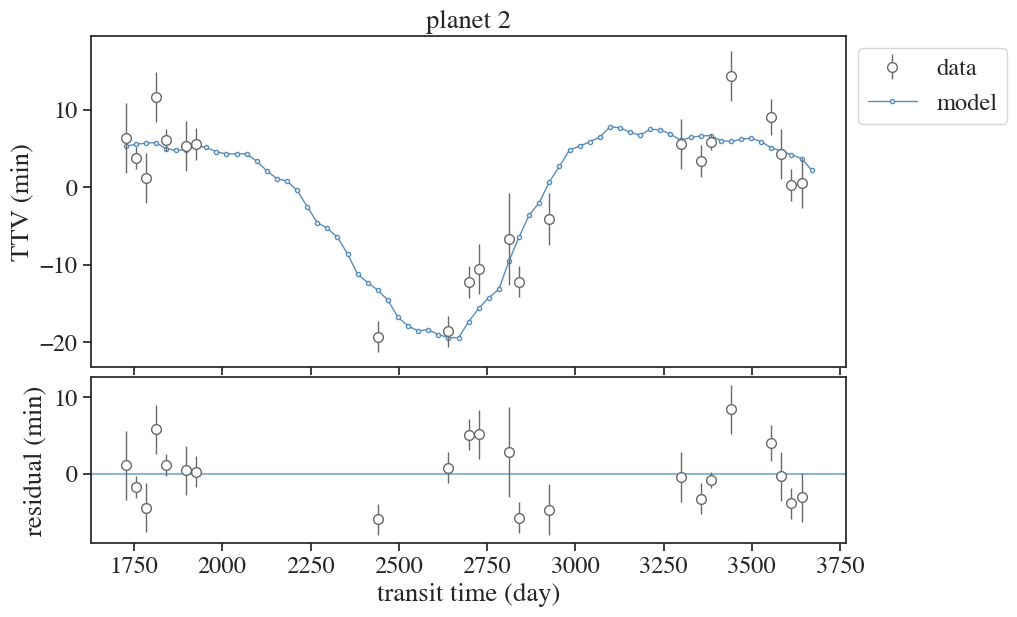

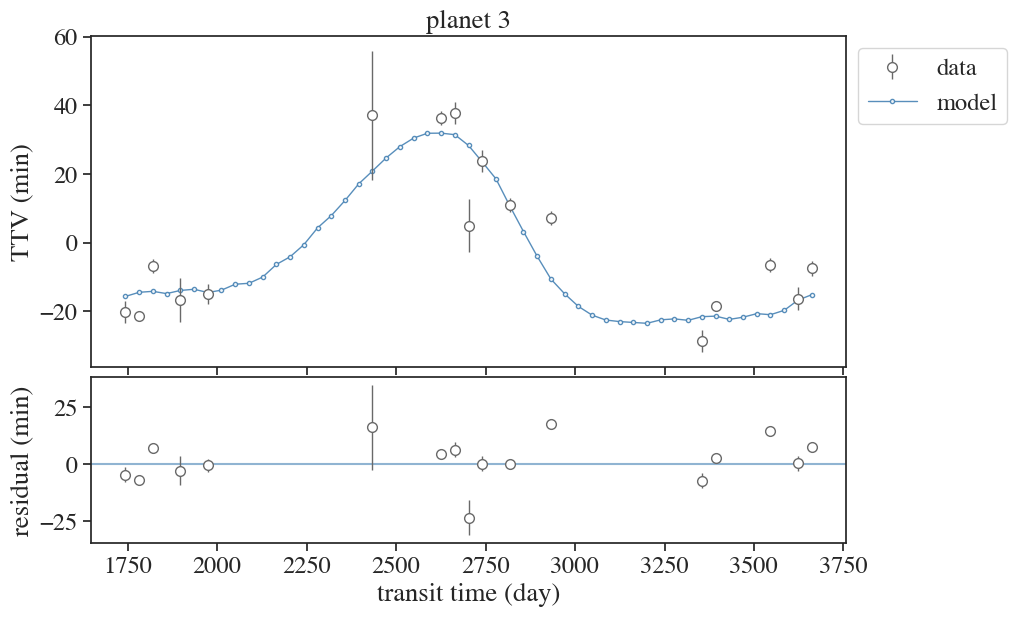

In [16]:
tcall = nt.get_transit_times_all_list(popt_full, truncate=False)
nt.plot_model(tcall, marker='.')
plt.show()

In [23]:
from astropy.constants import M_earth, M_sun
convert = M_sun.value / M_earth.value
print(1.48533451e-05*convert, 3.90801564e-06*convert, 2.36472194e-06*convert)

4.945363001098454 1.3011584813827624 0.7873248962593455


In [ ]:
from time import time
from numpyro.infer import MCMC, NUTS
# safer debugging config
kernel = NUTS(model_full, dense_mass=False, max_tree_depth=8)
mcmc_test = MCMC(kernel, num_warmup=50, num_samples=100, num_chains=2, progress_bar=True)

t0 = time()
mcmc_test.run(random.PRNGKey(123), param_bounds_ttv, param_bounds_transit)
t1 = time()
print(f"Elapsed: {t1-t0:.1f} s for (50 warmup + 100 samples) → ~{(t1-t0)/70:.3f} s per iteration (rough).")
mcmc_test.print_summary()

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Elapsed: 20.4 s for (50 warmup + 100 samples) → ~0.291 s per iteration (rough).


In [26]:
import arviz as az
idata = az.from_numpyro(mcmc_test)

In [27]:
az.rcParams['plot.max_subplots'] = 100

In [31]:
keys_gp = ['lna', 'lnc', 'lnjitter']

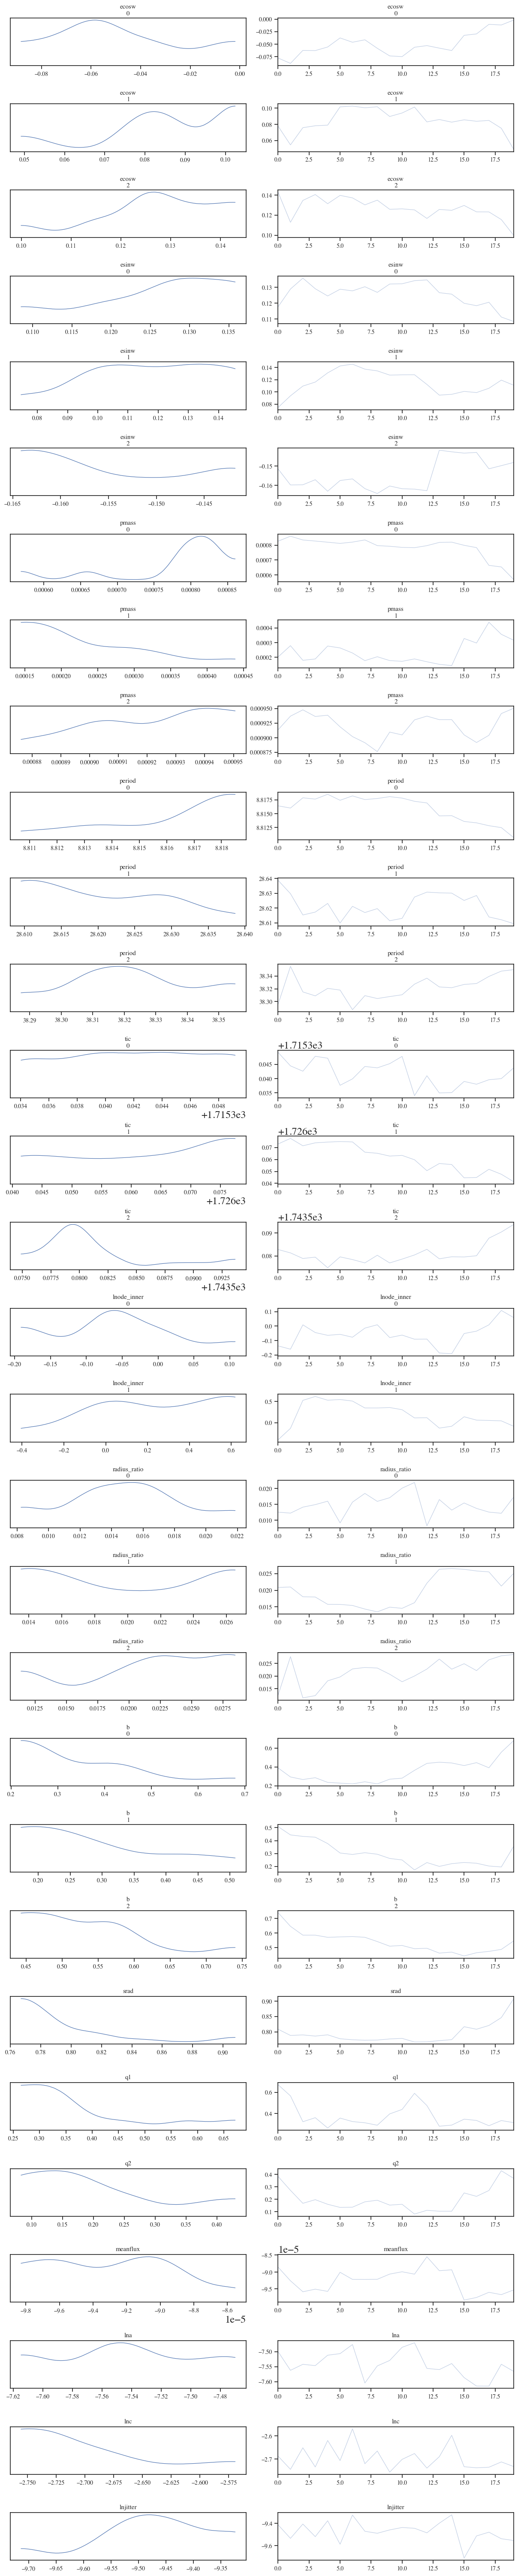

In [32]:
fig = az.plot_trace(mcmc_test, var_names=keys_ttv+['lnode_inner']+keys_transit+keys_gp, compact=False)
plt.tight_layout(pad=0.2)

In [34]:
import corner
idata.posterior['pmasse'] = idata.posterior['pmass'] / 3.003e-6
keys_ttv_ = [key if key!="pmass" else "pmasse" for key in keys_ttv]
fig = corner.corner(idata, var_names=keys_ttv_+['lnode_inner']+keys_transit+keys_gp, show_titles=True)

AssertionError: I don't believe that you want more dimensions than samples!

In [ ]:
samples = mcmc.get_samples()
fmodels = samples['fluxmodel'] + samples['meanflux'][:,None] + samples['gppred']
mu_phys = np.mean(samples['fluxmodel'] + samples['meanflux'][:,None], axis=0)
mu, sigma = np.mean(fmodels, axis=0), np.std(fmodels, axis=0)

In [21]:
from numpyro.infer import MCMC, NUTS
kernel = NUTS(model_full, 
              dense_mass=True, 
              init_strategy=init_to_value(values=popt_full), 
              target_accept_prob=0.95,
              max_tree_depth=11)

In [22]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [23]:
from jax import random
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, param_bounds_ttv, param_bounds_transit, extra_fields=('potential_energy', 'num_steps', 'adapt_state'), progress_bar=True)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
mcmc.print_summary()

In [ ]:
# save output
import dill
with open("toi1339_photodynamics_gp_mcmc.pkl", "wb") as f:
    dill.dump(mcmc, f)